In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from natsort import natsorted
import scanpy as sc

import torch
import os

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.set_printoptions(suppress=True)

%reload_ext autoreload
%autoreload 2

### Panel A

In [12]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/CordBloodDynamicRates/1213_100718/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [13]:
cluster_names = [
    'HSC/MPP 1', 'HSC/MPP 2', 'MEMP', 'Mast cell', 'Early Erythroid',
    'Mid Erythroid', 'Late Erythroid', 'NMP', 'Mono precur',
    'Monocyte', 'DC precursor', 'DC'
]

In [4]:
gillespie_dir='./trials/v1.2.0/checkpoints/CordBloodDynamicGillespie/1216_150034/models/'
gillespie_dir_valid = os.path.join(gillespie_dir, 'Clone 3')

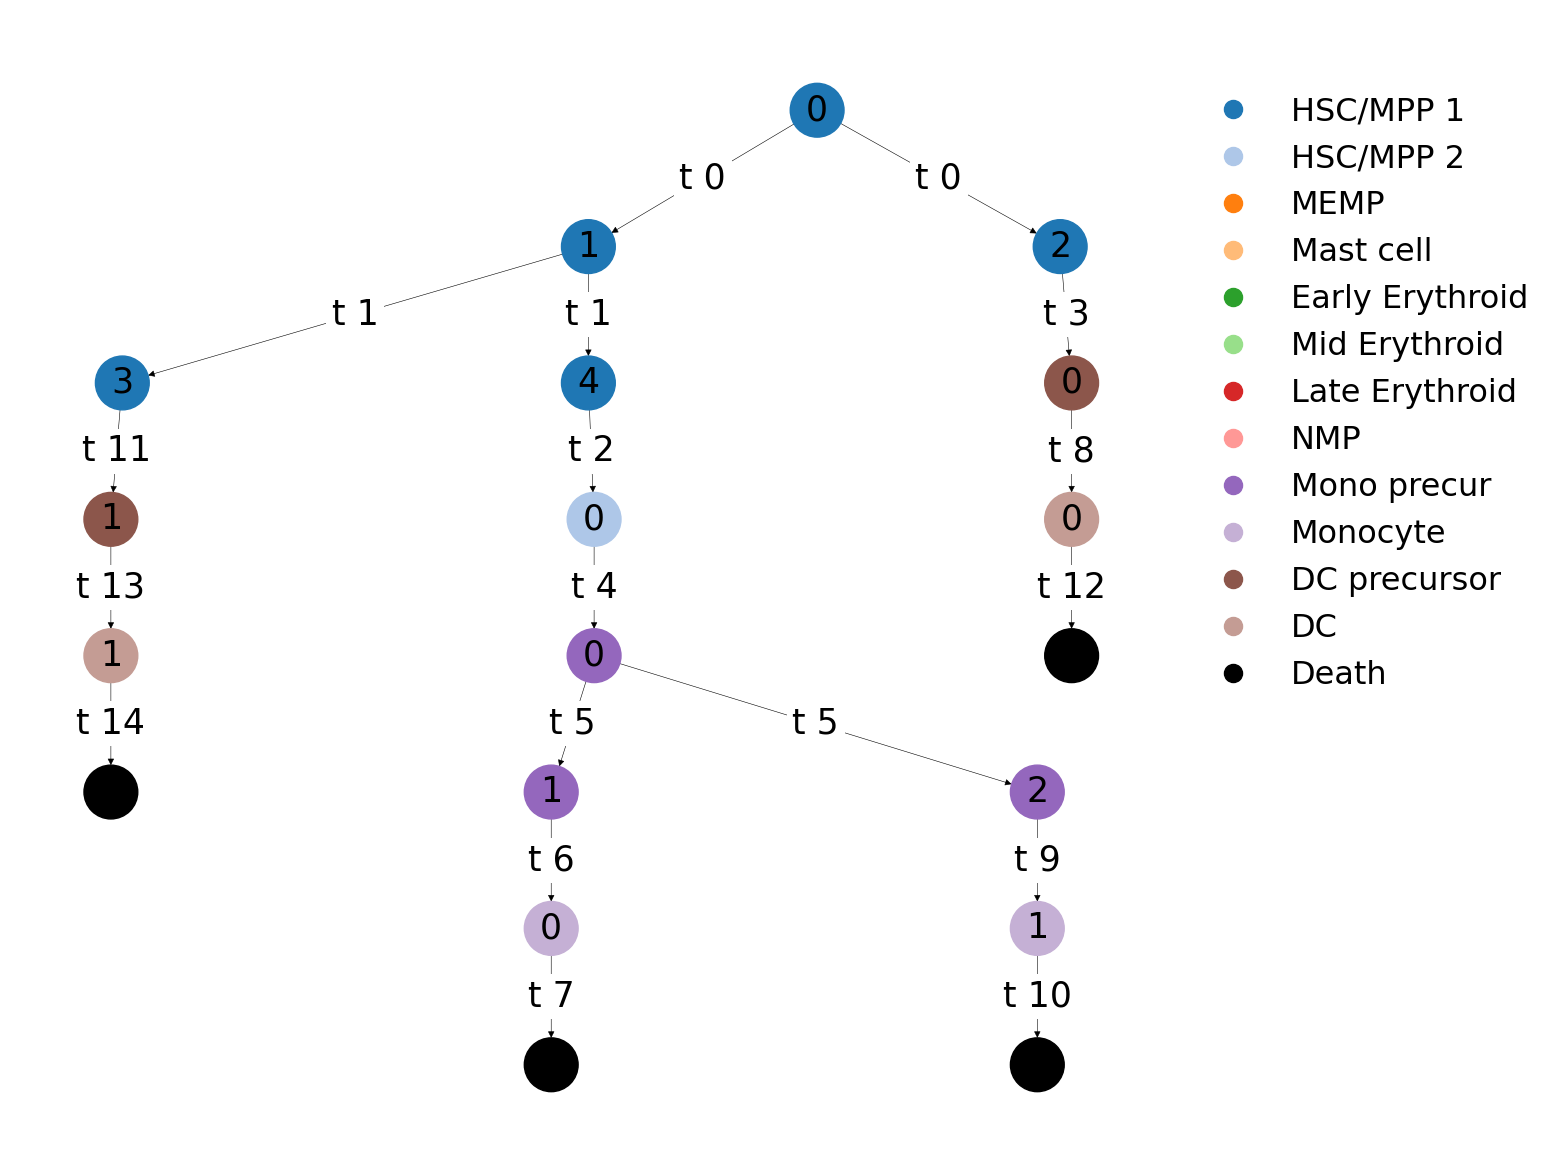

In [5]:
from clonaltrans.pl import visualize_gtree
visualize_gtree(
    96, 
    cluster_names, 
    gillespie_dir=gillespie_dir_valid, 
    show=True
)

### Panel B

In [14]:
# gillespie_dir='./trials/v1.2.0/checkpoints/CordBloodDynamicGillespie/1216_150034/models/'
gillespie_dir='./trials/Melania/checkpoints/CordBloodDynamicGillespie/0225_183937/models/'
gillespie_dir_valid = os.path.join(gillespie_dir, 'Clone 0')

In [10]:
from clonaltrans.pl import get_num_div
from natsort import natsorted

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        get_num_div(cluster_names, gillespie_dir=gillespie_dir_clones)

Total # of gillespie trials for ['models', 'Clone 0']: 1000
Total # of gillespie trials for ['models', 'Clone 1']: 1000
Total # of gillespie trials for ['models', 'Clone 2']: 1000
Total # of gillespie trials for ['models', 'Clone 3']: 1000
Total # of gillespie trials for ['models', 'Clone 4']: 1000
Total # of gillespie trials for ['models', 'Clone 5']: 1000
Total # of gillespie trials for ['models', 'Clone 6']: 1000
Total # of gillespie trials for ['models', 'Clone 7']: 1000
Total # of gillespie trials for ['models', 'Clone 8']: 1000
Total # of gillespie trials for ['models', 'Clone 10']: 1000
Total # of gillespie trials for ['models', 'Clone BG']: 1000


In [16]:
from clonaltrans.pl import get_div_distribution
import copy

distributions = []
length, mean, num_trails = [], [], []

for directory in natsorted(os.listdir(gillespie_dir)):
    if directory.startswith('Clone'):
        gillespie_dir_clones = os.path.join(gillespie_dir, directory)
        distribution, counts = get_div_distribution(gillespie_dir_clones, cluster_names, init_celltype=['HSC/MPP 1'])
        
        distributions.append(distribution)
        num_trails.append(counts)

In [17]:
print (num_trails)

[93, 0, 1000, 0, 57, 338, 263, 583, 0, 0, 148]


In [18]:
for key, value in distributions[0].items():
    print (key, len(value))

HSC/MPP 1 0
HSC/MPP 2 81
MEMP 90
Mast cell 90
Early Erythroid 87
Mid Erythroid 87
Late Erythroid 87
NMP 79
Mono precur 80
Monocyte 80
DC precursor 63
DC 0


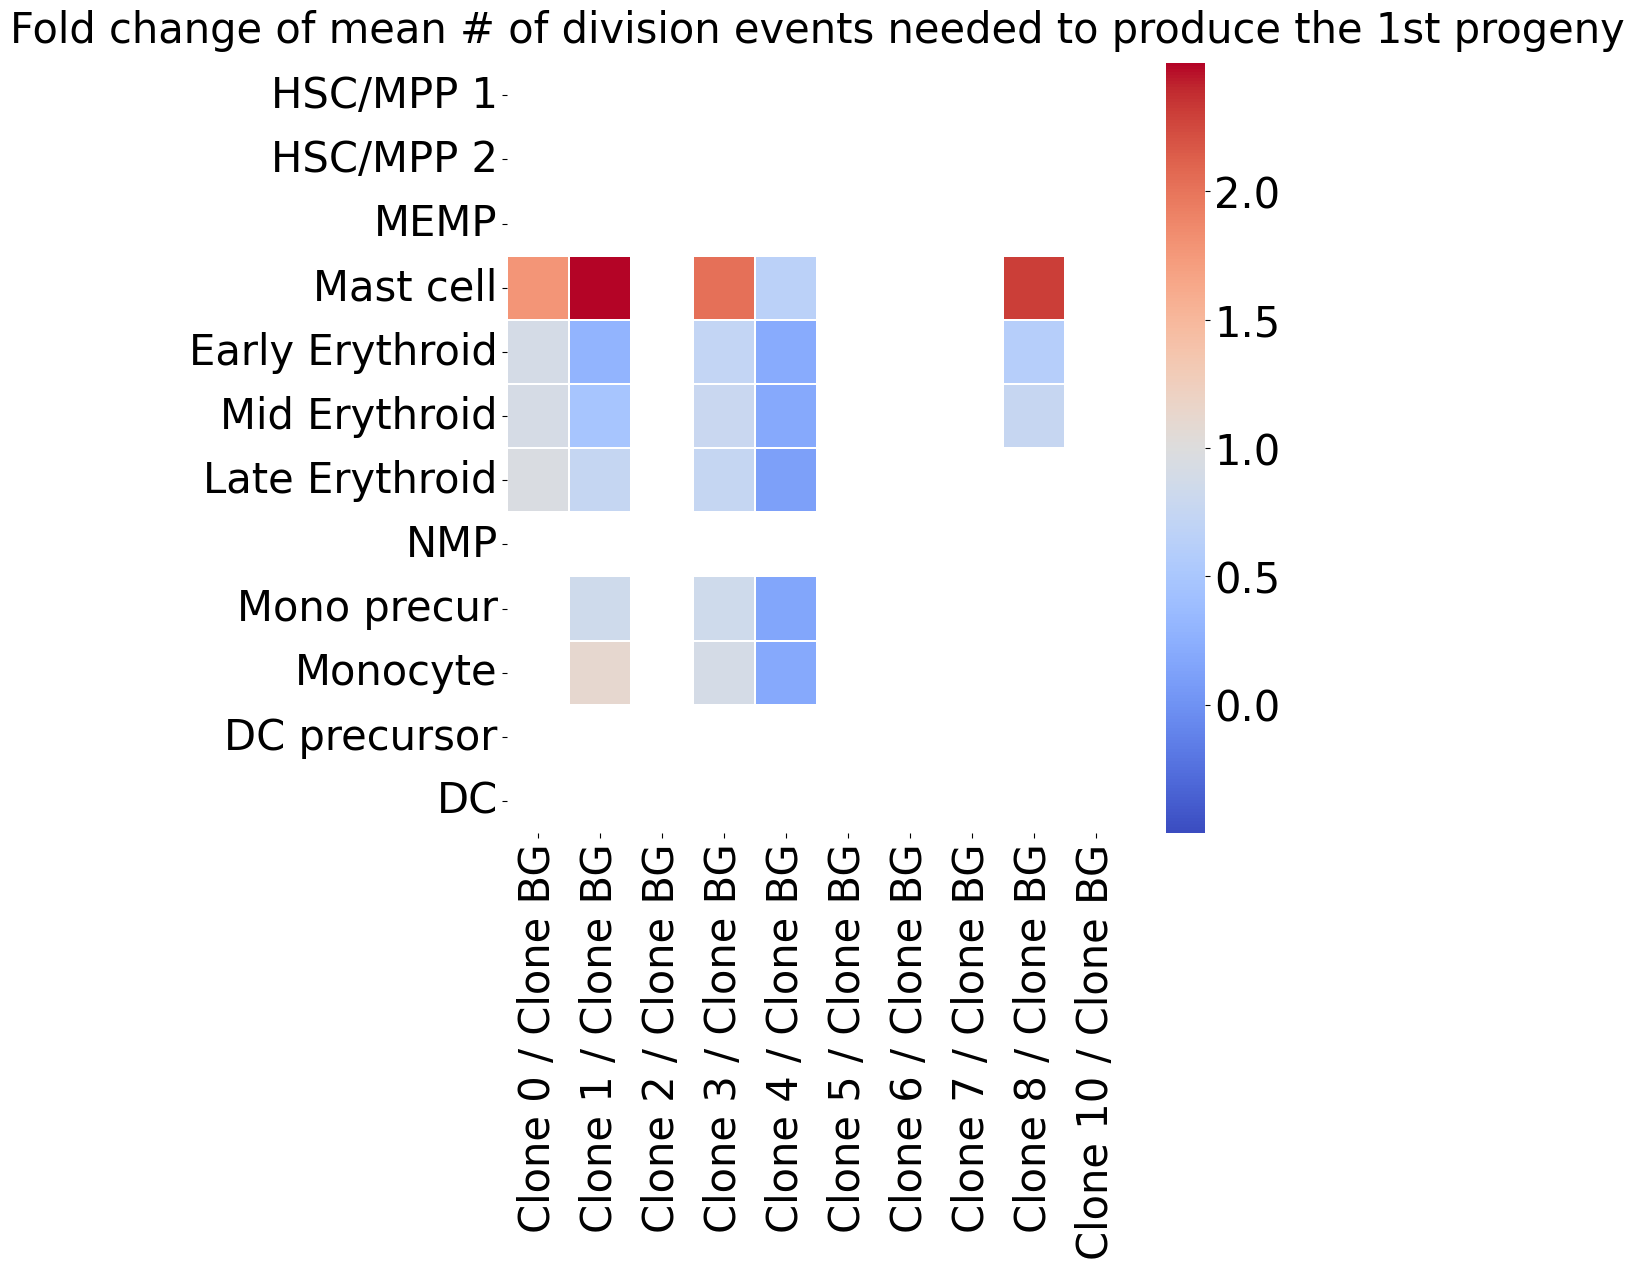

In [55]:
from clonaltrans.pl import clone_dist_diff_plot
clone_dist_diff_plot(distributions, model, save='cb_div_dist_diff')

### Panel C

In [6]:
gillespie_dir='./trials/v1.2.0/checkpoints/CordBloodDynamicGillespie/1216_150034/models/'
gillespie_dir_valid = os.path.join(gillespie_dir, 'Clone BG')

In [7]:
from clonaltrans.pl import visualize_num_div
visualize_num_div(
    cluster_names, 
    gillespie_dir=gillespie_dir_valid, 
    clone_name='Meta-clone BG',
    init_celltype=['HSC/MPP 2'],
    save=True
)

MEMP


Mast cell
Early Erythroid
Mid Erythroid
Late Erythroid
NMP
Mono precur
Monocyte
DC precursor
DC


### Panel D

In [20]:
num_trails

[93, 0, 1000, 0, 57, 338, 263, 583, 0, 0, 148]

In [ ]:
num_trails

[92, 0, 1000, 0, 89, 324, 294, 594, 0, 0, 141]

In [24]:
length = copy.deepcopy(distributions)

for idx, clone in enumerate(length):
    for key in clone.keys():
        if num_trails[idx] != 0:
            clone[key] = int(len(clone[key]) / num_trails[idx] * 1000)
        else:
            clone[key] = 0

In [25]:
df = pd.DataFrame(length)
del df['HSC/MPP 1']
df = df.drop(index=[1, 3, 8, 9])
df.index = ['0', '2', '4', '5', '6', '7', 'BG']
df

,HSC/MPP 2,MEMP,Mast cell,Early Erythroid,Mid Erythroid,Late Erythroid,NMP,Mono precur,Monocyte,DC precursor,DC
0,870,967,967,935,935,935,849,860,860,677,0
2,730,928,838,695,681,655,608,725,716,747,741
4,596,877,789,0,0,0,508,649,614,87,70
5,923,671,68,612,571,0,866,881,849,834,792
6,904,954,946,0,0,0,893,893,889,847,798
7,885,857,835,716,692,648,809,931,926,662,643
BG,912,932,925,777,777,722,878,945,945,817,810


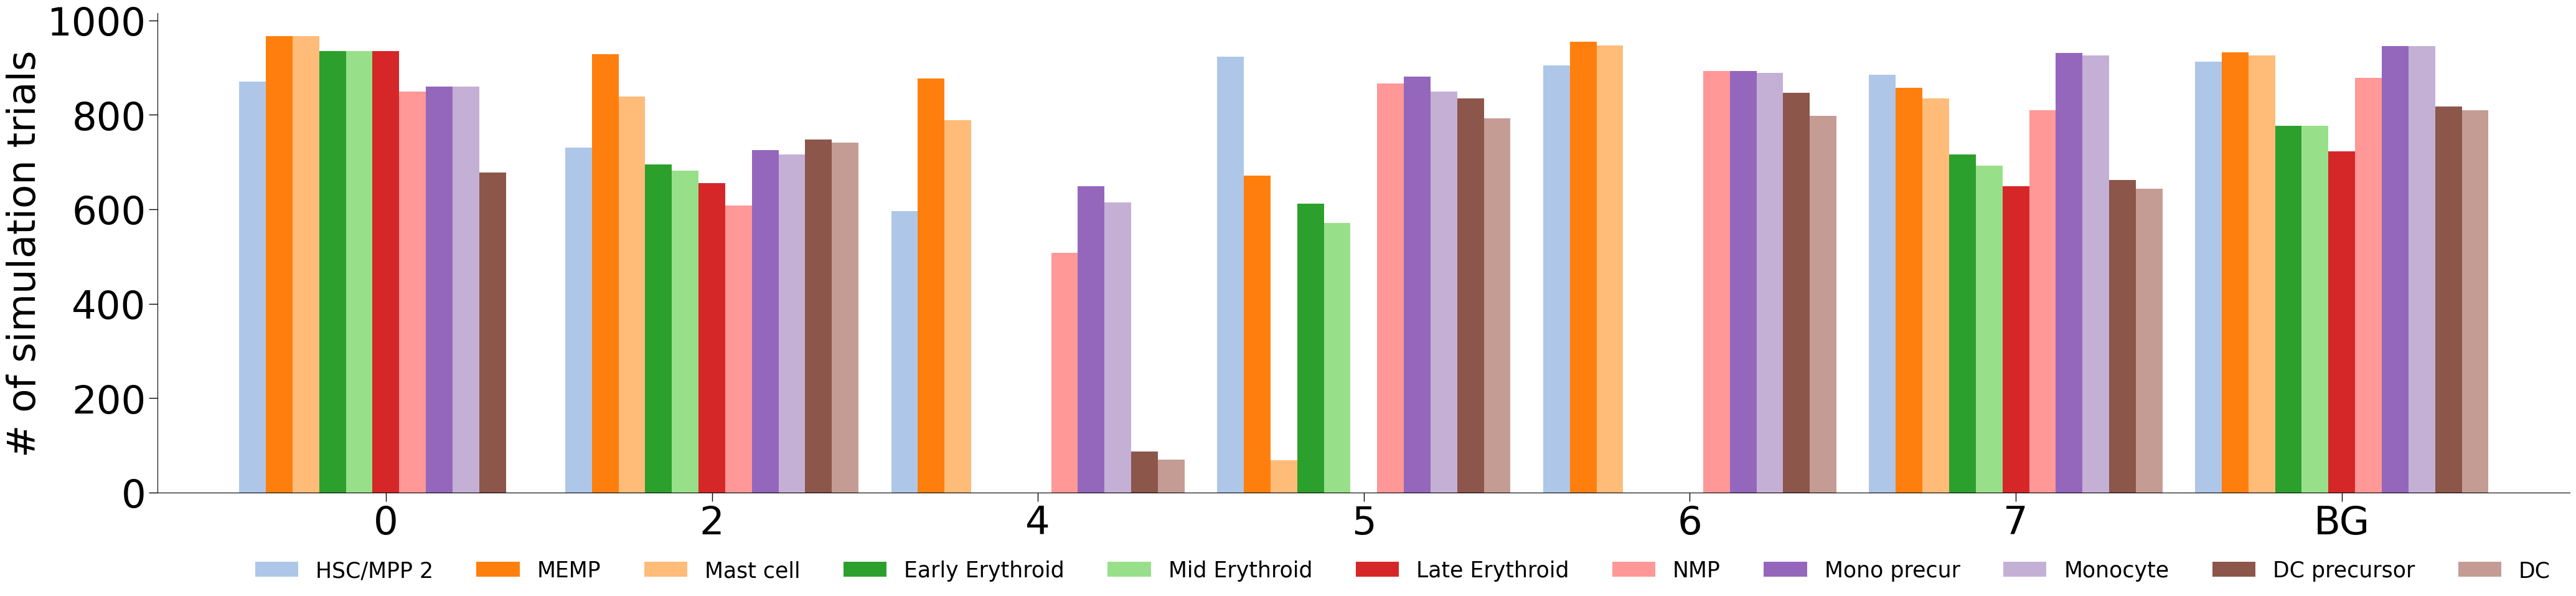

In [26]:
from clonaltrans.pl import succeed_trails_to_first
succeed_trails_to_first(df, 1000)

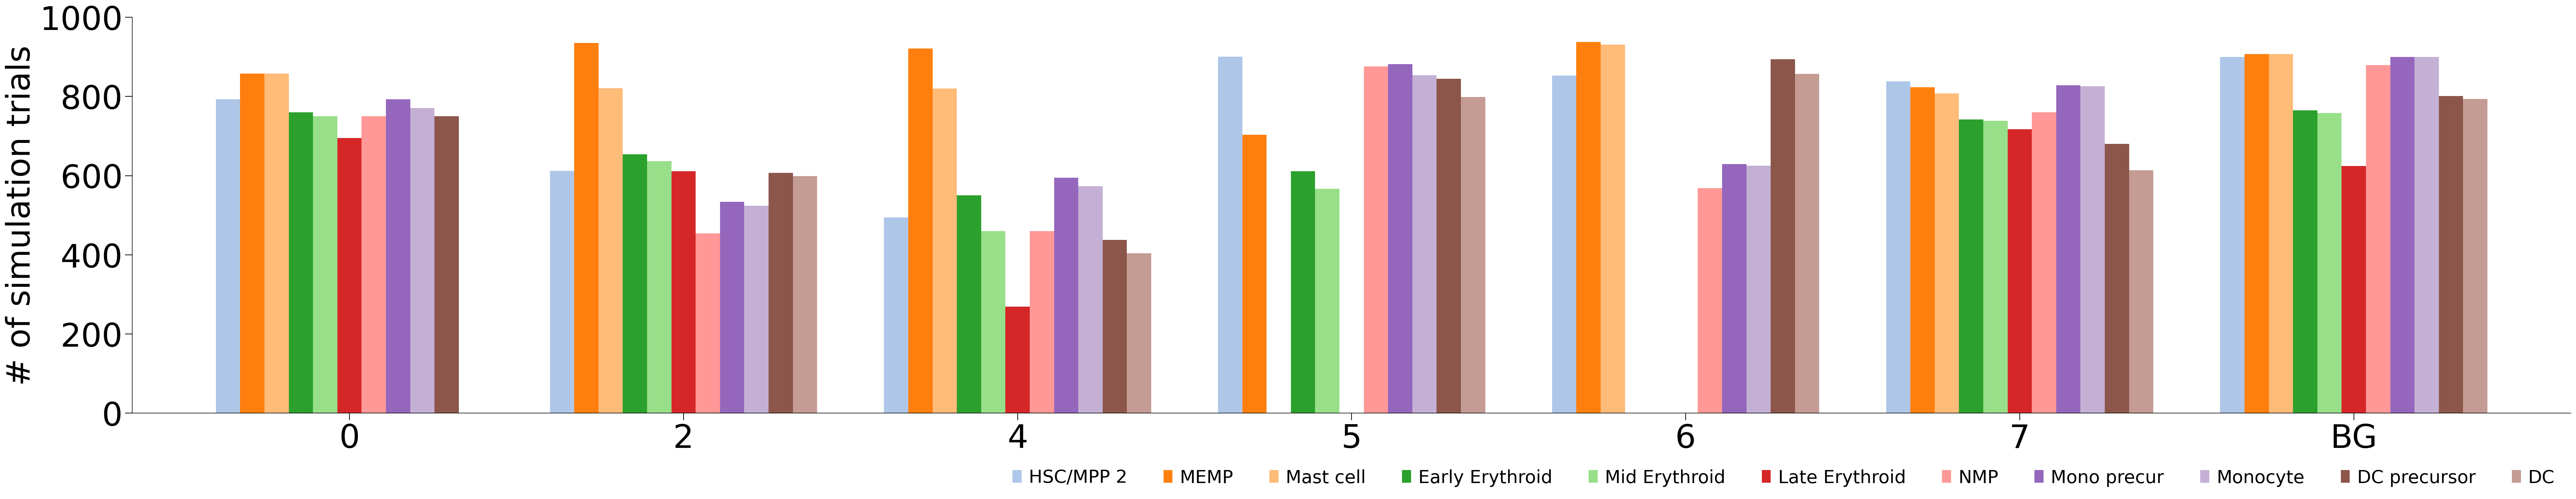

In [ ]:
from clonaltrans.pl import succeed_trails_to_first
succeed_trails_to_first(df, 1000, save='cb_potency')

In [127]:
adata = sc.read_h5ad('/ssd/users/mingzegao/clonaltrans/datasets/Human_CordBlood/adata_update.h5ad')
adata

AnnData object with n_obs × n_vars = 24885 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

In [190]:
prob_given_prog = []
for idx, row in adata.obs.iterrows():
    if row['Meta clones'] == '7' and row['def_lab'] != 'HSC/MPP 1':
        prob_given_prog.append(df.loc[row['Meta clones'], row['def_lab']] / 1000)
    else:
        prob_given_prog.append(0)

adata.obs['prob'] = prob_given_prog

In [174]:
adata_meta = adata[adata.obs['Meta clones'] == '0', :]
adata_meta

View of AnnData object with n_obs × n_vars = 2686 × 3462
    obs: 'Timepoint', 'gfp_late', 'GFP', 'Tissue', 'Batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'S_score', 'G2M_score', 'phase', 'label_full', 'label_red', 'clones', 'time_label_full', 'time_label_red', 'Meta clones', 'leiden', 'transferred_labels', 'prediction_score_max', 'dpt_pseudotime', 'def_lab', 'prob'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'gene_removed'
    uns: 'Batch_colors', 'Timepoint_colors', 'def_lab_colors', 'diffmap_evals', 'final_lab_colors', 'hvg', 'iroot', 'label_full_colors', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'phase_colors', 'pred_corr_colors', 'rank_genes_groups', 'transferred_labels_colors', 'umap'
    obsm: 'X_diffmap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'seurat'
    obsp: 'connectivities', 'distances'

/ssd/users/mingzegao/.conda/envs/clonetrans/lib/python3.9/site-packages/scanpy/plotting/_utils.py:715: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  color = color[sort]


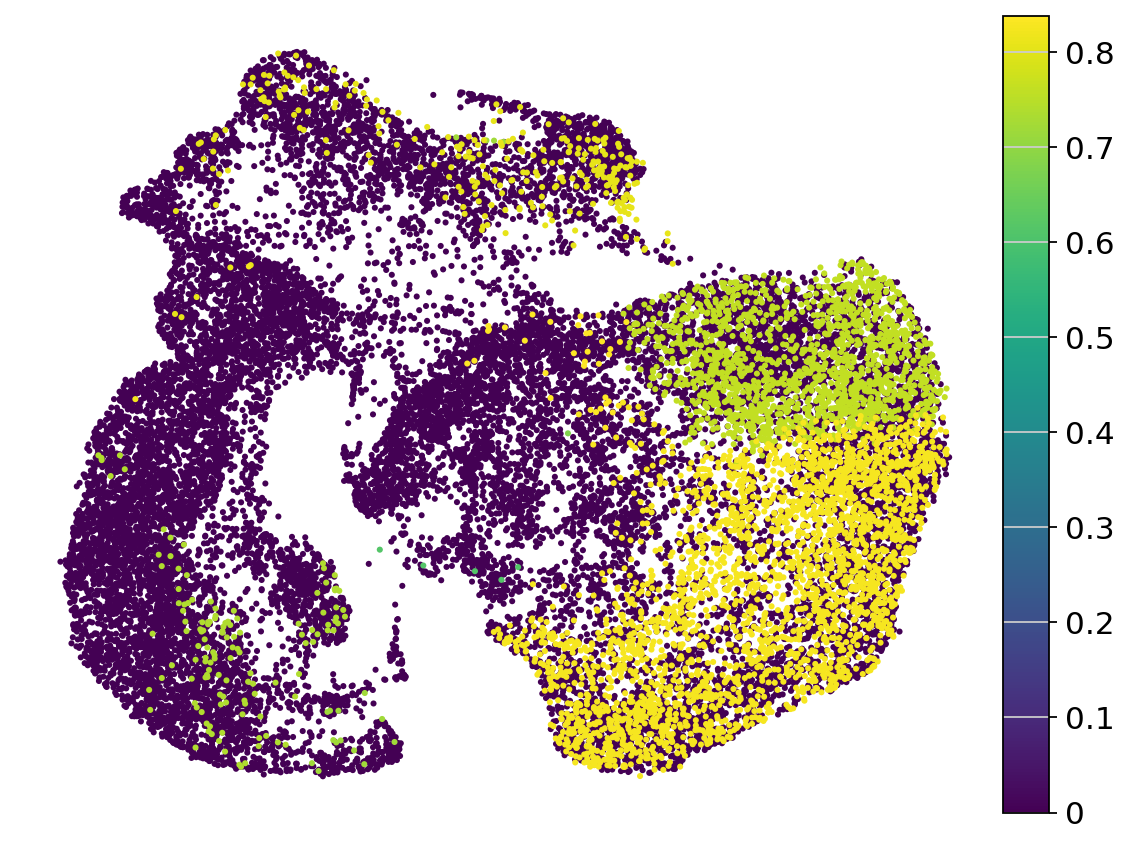

In [192]:
sc.set_figure_params(dpi_save=300, figsize=(7, 6), transparent=True)
sc.pl.scatter(
    adata, basis='umap', color='prob', 
    legend_loc='right margin', palette='coolwarm',
    size=30, frameon=False, title='',
    legend_fontsize=15
)